---
# VGG16 : `MNIST` (avec `Keras` - *data augmentation*)
---

## Packages

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
from keras import callbacks, layers, models
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.datasets import mnist

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

---
## 1. Données
---

### 1.1. Importation

In [ ]:
(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=1/5)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

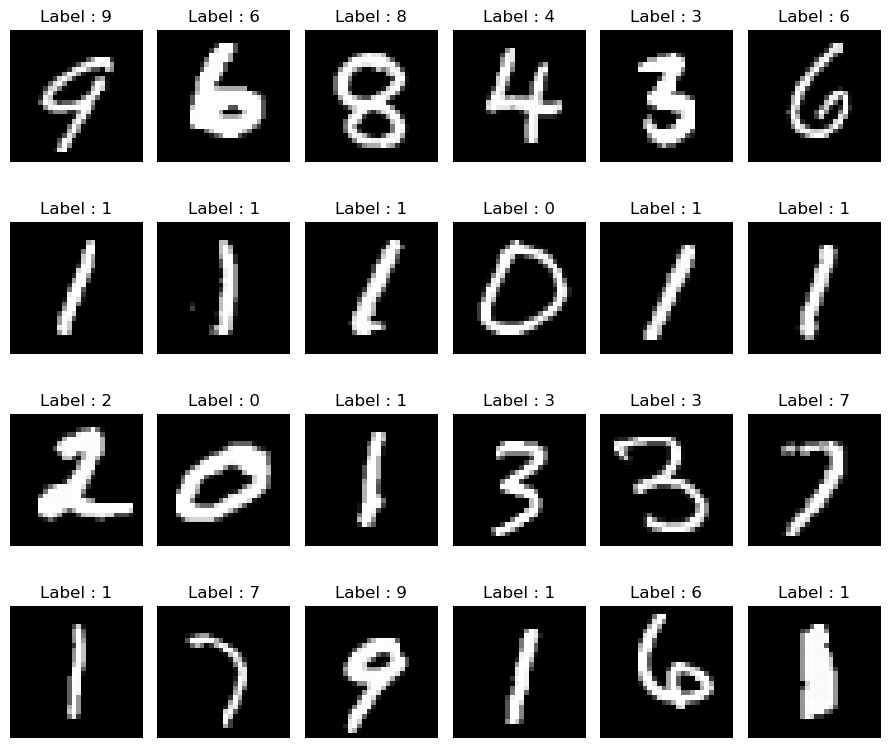

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Redimensionnement

On met les images au format $48\times 48$ pixels, sur 3 niveaux de couleur (RGB) :

In [4]:
dim_inputs_new = 48
n_colors       = 3

def resize_images(images):
  images = images.astype('float32')
  images = np.expand_dims(images, axis=-1)
  images = np.repeat(images, n_colors, axis=-1)
  images = tf.image.resize(images, [dim_inputs_new, dim_inputs_new])
  return images

X_train = resize_images(X_train)
X_valid = resize_images(X_valid)
X_test  = resize_images(X_test)

In [5]:
print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 48, 48, 3)
Dimensions de X_valid : (12000, 48, 48, 3)
Dimensions de X_test  : (10000, 48, 48, 3)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.4. Data augmentation

In [6]:
n_modif = 1

datagen = ImageDataGenerator(
    rotation_range     = 15,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    zoom_range         = 0.1
)

augmented_images = []
augmented_labels = []

for i in range(len(X_train)):
    img = X_train[i]
    img = np.expand_dims(img, axis=0)

    for _ in range(n_modif):
        aug_iter = datagen.flow(img, batch_size=1)
        aug_img = next(aug_iter)[0]
        augmented_images.append(aug_img)
        augmented_labels.append(y_train[i])

augmented_images = np.array(augmented_images)
augmented_labels = np.array(augmented_labels)

X_train = np.concatenate((X_train, augmented_images))
y_train = np.concatenate((y_train, augmented_labels))

In [7]:
print('Dimensions de X_train :', X_train.shape)
print('Dimensions de y_train :', y_train.shape)

Dimensions de X_train : (96000, 48, 48, 3)
Dimensions de y_train : (96000,)


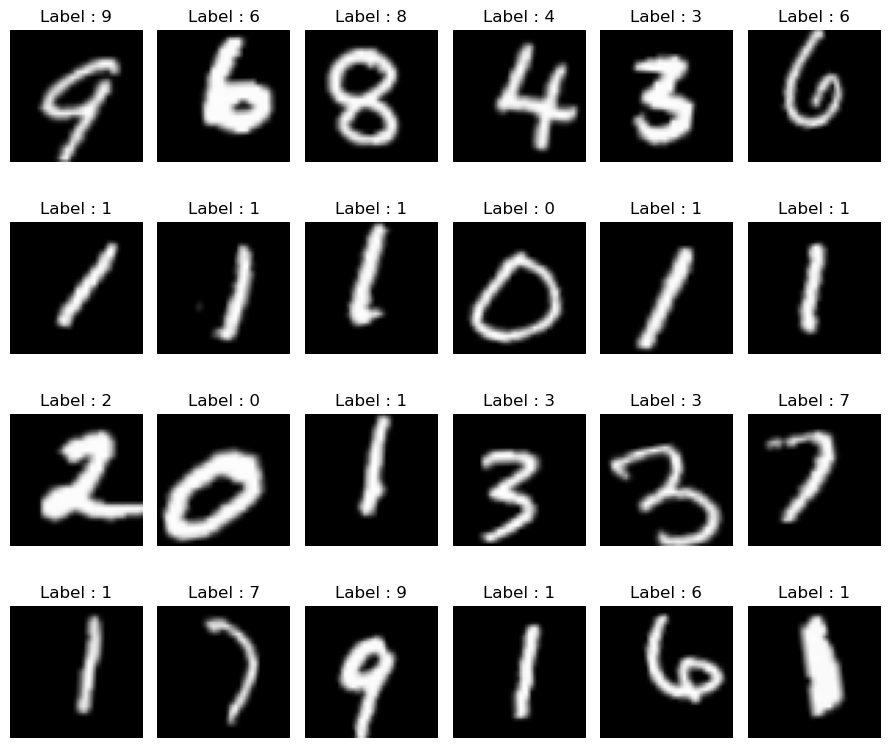

In [8]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(augmented_images[i].astype(np.uint8))
    ax.set_title(f'Label : {augmented_labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.5. Normalisation

Pour utiliser VGG16, on normalise les données en retirant les moyennes de chaque niveau de couleur sur le jeu de données imageNet :

In [9]:
X_train_norm = preprocess_input(X_train)
X_valid_norm = preprocess_input(X_valid)
X_test_norm  = preprocess_input(X_test)

---
## 2. VGG16
---

### 2.1. Architecture

In [10]:
dim_outputs = 10

n_units_hl = 256
dropout_hl = 0.2

model = keras.models.Sequential(name='CNN')

activation_input  = 'relu'
activation_output = 'softmax'

optimizer = 'adam'
loss      = 'categorical_crossentropy'
metrics   = ['accuracy']

input_tensor = layers.Input(shape=(dim_inputs_new, dim_inputs_new, n_colors))

model_prior = VGG16(weights='imagenet',
                    include_top=False,
                    input_tensor=input_tensor)

x = layers.Flatten()(model_prior.output)
x = layers.Dense(units=n_units_hl, activation=activation_input)(x)
x = layers.Dropout(rate=dropout_hl)(x)
output = layers.Dense(units=dim_outputs, activation=activation_output)(x)

model = models.Model(inputs=input_tensor, outputs=output)

for layer in model_prior.layers:
    layer.trainable = False

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 48, 48, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 48, 48, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 24, 24, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 24, 24, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 24, 24, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 12, 12, 128)       0     

### 2.2. Optimiseur

In [ ]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 5,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [12]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 300,
                 epochs          = 50,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/50
320/320 [==============================] - 277s 864ms/step - loss: 0.9846 - accuracy: 0.8101 - val_loss: 0.2369 - val_accuracy: 0.9257
Epoch 2/50
320/320 [==============================] - 320s 999ms/step - loss: 0.2790 - accuracy: 0.9112 - val_loss: 0.1853 - val_accuracy: 0.9427
Epoch 3/50
320/320 [==============================] - 251s 783ms/step - loss: 0.2182 - accuracy: 0.9294 - val_loss: 0.1582 - val_accuracy: 0.9508
Epoch 4/50
320/320 [==============================] - 254s 793ms/step - loss: 0.1893 - accuracy: 0.9387 - val_loss: 0.1488 - val_accuracy: 0.9538
Epoch 5/50
320/320 [==============================] - 255s 798ms/step - loss: 0.1682 - accuracy: 0.9443 - val_loss: 0.1451 - val_accuracy: 0.9528
Epoch 6/50
320/320 [==============================] - 256s 800ms/step - loss: 0.1531 - accuracy: 0.9497 - val_loss: 0.1354 - val_accuracy: 0.9568
Epoch 7/50
320/320 [==============================] - 258s 807ms/step - loss: 0.1439 - accuracy: 0.9523 - val_loss: 0.1325 -

### 2.4. Prévisions

In [13]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 [==============================] - 34s 107ms/step


array([[2.0774571e-15, 2.2059965e-06, 4.5883262e-06, 1.0072810e-07,
        1.3783039e-10, 9.5051012e-10, 5.3699693e-13, 9.9999309e-01,
        9.5739497e-14, 1.1910492e-10],
       [3.9910393e-12, 7.0148876e-10, 9.9999213e-01, 2.5741994e-07,
        2.1646770e-07, 2.5990337e-06, 1.1157629e-12, 4.6341670e-06,
        6.4499024e-11, 1.6106993e-07],
       [3.7873546e-17, 1.0000000e+00, 1.0810548e-13, 9.2156263e-13,
        7.1282125e-10, 1.9258824e-11, 2.8453507e-12, 6.9970896e-10,
        3.4976068e-15, 3.6690005e-11],
       [9.9999595e-01, 3.1685299e-13, 3.8122359e-09, 4.2073151e-11,
        8.9820359e-11, 5.0366765e-08, 3.0841809e-06, 1.9288138e-09,
        6.7485967e-10, 8.9810601e-07],
       [1.7298419e-07, 3.0516799e-07, 4.4056265e-09, 9.0409999e-09,
        9.9996924e-01, 6.7206784e-06, 2.2508514e-06, 5.5526024e-09,
        1.4298987e-06, 1.9894054e-05]], dtype=float32)

In [14]:
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_pred_classes[0:5]

array([7, 2, 1, 0, 4])

In [15]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.1244
Exactitude test : 0.9633
